## UMAP-based Label Transfer: patchseq (VISp inh) → minnie65 (inh)

Pipeline:
1. Load patchseq inhitatory morph features + MET-type cluster labels
2. Load minnie inhitatory skeleton-keys features
3. Identify shared features dynamically; drop NaN rows
4. Fit `StandardScaler` on patchseq, transform both
5. Fit `UMAP` on patchseq, `.transform()` minnie into the same embedding
6. 3-NN majority-vote label transfer from patchseq → minnie
7. Visualise

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer
from sklearn.neighbors import NearestNeighbors
from scipy.stats import mode
import umap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from utils import get_list_differences
import polars as pl
import os
from sklearn.preprocessing import LabelEncoder

%load_ext autoreload
%autoreload 2

In [2]:
DATA_ROOT = '/scratch/combined_datasets'

### Phase 1 — Load Data

In [3]:
# Patchseq inhitatory morphology features
df_ps_feat = pl.read_delta(os.path.join(DATA_ROOT, 'cellfeatures/inh_morph_features'))
df_ps_feat = df_ps_feat.filter(
    (pl.col('project_id') == 'visp_inh_patchseq') &
    (pl.col('feature_set_id') == 'inh_visp_morph_features')
)
print(f"Patchseq features: {df_ps_feat.shape}")
df_ps_feat.head(3)

Patchseq features: (520, 49)


id,axon_bias_x,axon_bias_y,axon_depth_pc_0,axon_depth_pc_1,axon_depth_pc_2,axon_depth_pc_3,axon_depth_pc_4,axon_depth_pc_5,axon_emd_with_basal_dendrite,axon_exit_distance,axon_exit_theta,axon_extent_x,axon_extent_y,axon_frac_above_basal_dendrite,axon_frac_below_basal_dendrite,axon_frac_intersect_basal_dendrite,axon_max_branch_order,axon_max_euclidean_distance,axon_max_path_distance,axon_mean_contraction,axon_num_branches,axon_soma_percentile_x,axon_soma_percentile_y,axon_total_length,basal_dendrite_bias_x,basal_dendrite_bias_y,basal_dendrite_calculate_number_of_stems,basal_dendrite_extent_x,basal_dendrite_extent_y,basal_dendrite_frac_above_axon,basal_dendrite_frac_below_axon,basal_dendrite_frac_intersect_axon,basal_dendrite_max_branch_order,basal_dendrite_max_euclidean_distance,basal_dendrite_max_path_distance,basal_dendrite_mean_contraction,basal_dendrite_mean_diameter,basal_dendrite_num_branches,basal_dendrite_soma_percentile_x,basal_dendrite_soma_percentile_y,basal_dendrite_stem_exit_down,basal_dendrite_stem_exit_side,basal_dendrite_stem_exit_up,basal_dendrite_total_length,basal_dendrite_total_surface_area,soma_aligned_dist_from_pia,project_id,feature_set_id
str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i32,f32,f32,f32,i32,f32,f32,f32,f32,f32,i32,f32,f32,f32,f32,f32,i32,f32,f32,f32,f32,i32,f32,f32,f32,f32,f32,f32,f32,f32,str,str
"""601506507""",180.833191,-249.83075,-255.225098,23.857132,-264.429962,-299.517761,-400.345398,28.557966,22.687988,21.366434,0.753477,393.747833,364.079346,0.0,0.0,1.0,12,452.063904,794.445679,0.79993,39,0.42234,0.872872,3477.662354,124.994995,106.454025,2,184.329514,677.569275,0.344419,0.005637,0.649944,6,411.633698,523.7005,0.788084,0.918386,22,0.137298,0.522512,0.0,0.5,0.5,2518.295654,7207.459961,357.159821,"""visp_inh_patchseq""","""inh_visp_morph_features"""
"""601790961""",25.481123,434.251068,-216.809891,-153.378464,-303.881836,-117.440689,241.134079,-7.542952,39.412388,23.363827,0.413627,436.951447,718.174683,0.463688,0.0,0.536312,28,583.322144,1053.978027,0.864694,289,0.475137,0.080489,14777.348633,36.594662,-45.43544,6,313.066193,407.682129,0.0,0.01831,0.98169,8,272.892242,322.548553,0.851932,0.870701,42,0.480986,0.462676,0.0,0.666667,0.333333,4256.09375,11691.149414,663.103027,"""visp_inh_patchseq""","""inh_visp_morph_features"""
"""601803754""",42.650597,104.697845,1157.151978,3052.272949,-16.743603,996.874817,318.205719,-209.40094,16.735521,15.924714,0.43383,569.871033,229.078171,0.513019,0.0,0.486981,30,330.553345,861.607483,0.750487,691,0.486983,0.008414,30913.128906,19.051867,16.631531,8,234.991699,185.685074,0.0,0.017616,0.982384,6,249.564148,281.814117,0.776152,0.882682,62,0.460057,0.33347,0.125,0.625,0.25,4108.235352,11384.542969,170.365067,"""visp_inh_patchseq""","""inh_visp_morph_features"""


In [4]:
# Diagnose: how many clustermembership rows per patchseq cell?
df_ps_labels_raw = (
    pl.read_delta(os.path.join(DATA_ROOT, 'clustermembership'))
    .filter(pl.col('project_id') == 'visp_inh_patchseq')
)

rows_per_cell = (
    df_ps_labels_raw
    .group_by('item')
    .agg(pl.len().alias('n_rows'))
)
print("Rows per cell distribution:")
print(rows_per_cell['n_rows'].value_counts().sort('n_rows'))

# Check what hierarchy categories are present
df_clusters = pl.read_delta(os.path.join(DATA_ROOT, 'cluster'))
df_ps_labels_with_level = df_ps_labels_raw.join(
    df_clusters.select(['id', 'level', 'heirachy_category']),
    left_on='cluster', right_on='id',
    how='left'
)
print("\nClusters by hierarchy category:")
print(df_ps_labels_with_level.group_by('heirachy_category').agg(pl.len().alias('count')).sort('count', descending=True))

Rows per cell distribution:
shape: (1, 2)
┌────────┬───────┐
│ n_rows ┆ count │
│ ---    ┆ ---   │
│ u32    ┆ u32   │
╞════════╪═══════╡
│ 3      ┆ 495   │
└────────┴───────┘

Clusters by hierarchy category:
shape: (3, 2)
┌───────────────────┬───────┐
│ heirachy_category ┆ count │
│ ---               ┆ ---   │
│ str               ┆ u32   │
╞═══════════════════╪═══════╡
│ major_class       ┆ 990   │
│ class             ┆ 990   │
│ cluster           ┆ 495   │
└───────────────────┴───────┘


In [5]:
# Keep only the deepest (most specific) cluster label per patchseq cell.
# Patchseq cells map to visp_met_types clusters -- filter cluster table to that project first.
df_clusters_met = df_clusters.filter(pl.col('project_id') == 'visp_met_types')

df_ps_labels = (
    df_ps_labels_raw
    .select(['item', 'cluster'])
    .join(
        df_clusters_met.select(['id', 'level', 'heirachy_category']),
        left_on='cluster', right_on='id',
        how='left'
    )
    # Per cell, keep the row with the highest level (deepest / most specific)
    .sort('level', descending=True, nulls_last=True)
    .group_by('item')
    .first()
    .select(['item', 'cluster', 'level', 'heirachy_category'])
)

print('Label distribution by hierarchy category:')
print(df_ps_labels.group_by('heirachy_category').agg(pl.len().alias('count')).sort('count', descending=True))
print(f'\nUnique cells:  {df_ps_labels["item"].n_unique()}')
print(f'Unique labels: {df_ps_labels["cluster"].n_unique()}')
df_ps_labels.head(5)

Label distribution by hierarchy category:
shape: (1, 2)
┌───────────────────┬───────┐
│ heirachy_category ┆ count │
│ ---               ┆ ---   │
│ str               ┆ u32   │
╞═══════════════════╪═══════╡
│ cluster           ┆ 495   │
└───────────────────┴───────┘

Unique cells:  495
Unique labels: 28


item,cluster,level,heirachy_category
str,str,i64,str
"""829185764""","""Vip-MET-4""",2,"""cluster"""
"""786228558""","""Pvalb-MET-4""",2,"""cluster"""
"""844908436""","""Vip-MET-1""",2,"""cluster"""
"""823830483""","""Pvalb-MET-4""",2,"""cluster"""
"""688115867""","""Sst-MET-10""",2,"""cluster"""


In [6]:
# Join leaf-level labels onto features
df_ps = df_ps_feat.join(df_ps_labels, left_on='id', right_on='item', how='inner')
print(f"Patchseq after label join: {df_ps.shape}")
df_ps.head(5)

Patchseq after label join: (495, 52)


id,axon_bias_x,axon_bias_y,axon_depth_pc_0,axon_depth_pc_1,axon_depth_pc_2,axon_depth_pc_3,axon_depth_pc_4,axon_depth_pc_5,axon_emd_with_basal_dendrite,axon_exit_distance,axon_exit_theta,axon_extent_x,axon_extent_y,axon_frac_above_basal_dendrite,axon_frac_below_basal_dendrite,axon_frac_intersect_basal_dendrite,axon_max_branch_order,axon_max_euclidean_distance,axon_max_path_distance,axon_mean_contraction,axon_num_branches,axon_soma_percentile_x,axon_soma_percentile_y,axon_total_length,basal_dendrite_bias_x,basal_dendrite_bias_y,basal_dendrite_calculate_number_of_stems,basal_dendrite_extent_x,basal_dendrite_extent_y,basal_dendrite_frac_above_axon,basal_dendrite_frac_below_axon,basal_dendrite_frac_intersect_axon,basal_dendrite_max_branch_order,basal_dendrite_max_euclidean_distance,basal_dendrite_max_path_distance,basal_dendrite_mean_contraction,basal_dendrite_mean_diameter,basal_dendrite_num_branches,basal_dendrite_soma_percentile_x,basal_dendrite_soma_percentile_y,basal_dendrite_stem_exit_down,basal_dendrite_stem_exit_side,basal_dendrite_stem_exit_up,basal_dendrite_total_length,basal_dendrite_total_surface_area,soma_aligned_dist_from_pia,project_id,feature_set_id,cluster,level,heirachy_category
str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i32,f32,f32,f32,i32,f32,f32,f32,f32,f32,i32,f32,f32,f32,f32,f32,i32,f32,f32,f32,f32,i32,f32,f32,f32,f32,f32,f32,f32,f32,str,str,str,i64,str
"""601506507""",180.833191,-249.83075,-255.225098,23.857132,-264.429962,-299.517761,-400.345398,28.557966,22.687988,21.366434,0.753477,393.747833,364.079346,0.0,0.0,1.0,12,452.063904,794.445679,0.79993,39,0.42234,0.872872,3477.662354,124.994995,106.454025,2,184.329514,677.569275,0.344419,0.005637,0.649944,6,411.633698,523.7005,0.788084,0.918386,22,0.137298,0.522512,0.0,0.5,0.5,2518.295654,7207.459961,357.159821,"""visp_inh_patchseq""","""inh_visp_morph_features""","""Vip-MET-2""",2,"""cluster"""
"""601803754""",42.650597,104.697845,1157.151978,3052.272949,-16.743603,996.874817,318.205719,-209.40094,16.735521,15.924714,0.43383,569.871033,229.078171,0.513019,0.0,0.486981,30,330.553345,861.607483,0.750487,691,0.486983,0.008414,30913.128906,19.051867,16.631531,8,234.991699,185.685074,0.0,0.017616,0.982384,6,249.564148,281.814117,0.776152,0.882682,62,0.460057,0.33347,0.125,0.625,0.25,4108.235352,11384.542969,170.365067,"""visp_inh_patchseq""","""inh_visp_morph_features""","""Sst-MET-3""",2,"""cluster"""
"""601808698""",42.20002,342.307251,277.368073,-594.419434,-899.916687,833.364502,-405.968842,475.309875,10.474801,0.0,0.193495,423.536346,588.806213,0.177495,0.002972,0.819533,28,492.171387,862.05603,0.844058,483,0.427856,0.018089,15565.37207,66.103867,99.791977,4,365.984375,229.163132,0.0,0.0,1.0,7,217.113831,261.844452,0.891588,0.729696,42,0.316378,0.047513,0.0,1.0,0.0,2309.168213,5284.628418,460.737885,"""visp_inh_patchseq""","""inh_visp_morph_features""","""Sst-MET-8""",2,"""cluster"""
"""601810307""",89.759903,239.040894,1201.597412,-121.156464,890.41394,-553.118469,130.516998,254.212463,12.408631,28.647764,0.058997,375.706818,348.430023,0.112132,0.0,0.887868,36,351.588165,912.201355,0.842963,515,0.451587,0.023353,19300.591797,15.288828,115.287704,6,234.766724,297.006195,0.0,0.012564,0.987436,9,217.818817,269.330078,0.900498,0.834698,48,0.454165,0.198232,0.333333,0.666667,0.0,3226.120605,8470.180664,271.6492,"""visp_inh_patchseq""","""inh_visp_morph_features""","""Sst-MET-3""",2,"""cluster"""
"""601811091""",5.65369,458.869812,-511.866852,-88.543892,200.666916,29.293745,204.378708,32.735226,39.501293,38.019691,0.216328,686.436646,1032.651489,0.388013,0.01873,0.593257,21,819.759033,1297.407471,0.850263,181,0.374975,0.106615,13722.331055,34.097435,120.777557,4,540.244202,463.378998,0.0,0.0,1.0,7,345.869995,391.342163,0.908831,0.667167,38,0.24428,0.430627,0.5,0.25,0.25,3468.154053,7262.180664,758.470337,"""visp_inh_patchseq""","""inh_visp_morph_features""","""Sst-MET-13""",2,"""cluster"""


In [7]:
# Minnie65 inhitatory skeleton-keys features
df_mn = pl.read_delta(os.path.join(DATA_ROOT, 'cellfeatures/minnie_inh_skel_keys'))
df_mn = df_mn.filter(
    (pl.col('project_id') == 'minnie65') &
    (pl.col('feature_set_id') == 'minnie_inh_skel_keys')
)
print(f"Minnie features: {df_mn.shape}")
df_mn.head(3)

Minnie features: (163, 54)


id,axon_bias_x,axon_bias_y,axon_depth_pc_0,axon_depth_pc_1,axon_depth_pc_2,axon_depth_pc_3,axon_depth_pc_4,axon_depth_pc_5,axon_emd_with_basal_dendrite,axon_exit_distance,axon_exit_theta,axon_extent_x,axon_extent_y,axon_frac_above_basal_dendrite,axon_frac_below_basal_dendrite,axon_frac_intersect_basal_dendrite,axon_max_branch_order,axon_max_euclidean_distance,axon_max_path_distance,axon_mean_contraction,axon_num_branches,axon_soma_percentile_x,axon_soma_percentile_y,axon_total_length,basal_dendrite_bias_x,basal_dendrite_bias_y,basal_dendrite_calculate_number_of_stems,basal_dendrite_depth_pc_0,basal_dendrite_depth_pc_1,basal_dendrite_depth_pc_2,basal_dendrite_depth_pc_3,basal_dendrite_depth_pc_4,basal_dendrite_extent_x,basal_dendrite_extent_y,basal_dendrite_frac_above_axon,basal_dendrite_frac_below_axon,basal_dendrite_frac_intersect_axon,basal_dendrite_max_branch_order,basal_dendrite_max_euclidean_distance,basal_dendrite_max_path_distance,basal_dendrite_mean_contraction,basal_dendrite_mean_diameter,basal_dendrite_num_branches,basal_dendrite_soma_percentile_x,basal_dendrite_soma_percentile_y,basal_dendrite_stem_exit_down,basal_dendrite_stem_exit_side,basal_dendrite_stem_exit_up,basal_dendrite_total_length,basal_dendrite_total_surface_area,soma_aligned_dist_from_pia,project_id,feature_set_id
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""252232""",0.278182,-0.704644,-0.514704,0.907184,-0.410158,-0.577201,-1.082056,-0.350367,-0.891958,0.539694,0.125603,-1.353153,-2.165044,-0.680313,-0.439253,0.905926,-1.472311,-1.867711,-1.513612,0.359019,-1.310776,0.38231,1.317321,-1.377556,-0.06099,-0.563363,-1.606539,-0.088187,0.272273,-0.087323,-0.509983,-0.281063,-0.861403,-1.150573,-0.362129,0.938783,-0.553497,-0.051069,-0.776839,-0.592371,-0.182963,-1.845449,-0.115242,0.282602,1.535778,-0.635782,0.691239,-0.055458,-0.270077,-1.302811,-1.775909,"""minnie65""","""minnie_inh_skel_keys"""
"""255120""",0.854395,-0.736089,-0.384483,1.23863,-0.336423,-0.474622,-0.980076,-0.173595,-1.090603,-1.220057,0.238555,-0.943521,-1.954179,-0.680313,-0.439253,0.905926,-1.295199,-0.625425,-0.365869,0.054527,-1.270358,0.022855,1.520639,-1.299635,0.04893,-0.393175,0.001974,-0.116905,0.326048,-0.161772,-0.527452,-0.263893,-0.885513,-0.944446,-0.105658,-0.055715,0.117948,-0.582405,-0.767567,-0.260462,-3.654206,0.600567,-0.236497,-0.053523,1.209115,-0.05887,0.114328,-0.055458,-0.25705,-0.983592,-1.654243,"""minnie65""","""minnie_inh_skel_keys"""
"""255129""",-0.490082,-1.381988,0.238187,2.77303,-0.05753,0.151335,-0.49576,0.297882,-0.750664,1.105008,0.349527,-0.357008,-1.046268,-0.652544,-0.405244,0.860891,0.121697,-0.474256,-0.915246,0.396852,-0.568089,-0.963206,0.427328,-0.646198,0.134431,-0.712619,-1.606539,-0.305317,0.566913,-0.543252,-0.399137,-0.036794,-0.148154,-0.593476,-0.362129,-0.536598,0.697275,-0.405293,-0.413238,-0.292047,0.716057,-0.328064,-0.079876,-0.453457,1.295109,-0.635782,0.27916,0.356622,-0.104537,-0.517526,-1.504439,"""minnie65""","""minnie_inh_skel_keys"""


### Phase 2 — Feature Harmonization

In [8]:
META_COLS = {'id', 'project_id', 'feature_set_id', 'cluster'}

ps_feat_cols = [c for c in df_ps.columns if c not in META_COLS]
mn_feat_cols = [c for c in df_mn.columns if c not in META_COLS]

only_in_ps, only_in_mn = get_list_differences(ps_feat_cols, mn_feat_cols, return_lists=True)
shared_features = sorted(set(ps_feat_cols) & set(mn_feat_cols))

print(f"Shared features:    {len(shared_features)}")
print(f"Only in patchseq:   {len(only_in_ps)}  → {only_in_ps}")
print(f"Only in minnie:     {len(only_in_mn)}  → {only_in_mn}")

ONLY IN A                      | ONLY IN B                     
------------------------------------------------------------
heirachy_category              | basal_dendrite_depth_pc_3     
level                          | basal_dendrite_depth_pc_4     
                               | basal_dendrite_depth_pc_2     
                               | basal_dendrite_depth_pc_1     
                               | basal_dendrite_depth_pc_0     


Shared features:    46
Only in patchseq:   2  → ['heirachy_category', 'level']
Only in minnie:     5  → ['basal_dendrite_depth_pc_3', 'basal_dendrite_depth_pc_4', 'basal_dendrite_depth_pc_2', 'basal_dendrite_depth_pc_1', 'basal_dendrite_depth_pc_0']


In [9]:
# Subset to shared features, convert to pandas
df_ps_pd = df_ps.select(shared_features + ['cluster']).to_pandas()
df_mn_pd = df_mn.select(shared_features + ['id']).to_pandas()

# Drop NaN rows and report
ps_before, mn_before = len(df_ps_pd), len(df_mn_pd)
df_ps_pd = df_ps_pd.dropna(subset=shared_features)
df_mn_pd = df_mn_pd.dropna(subset=shared_features)

print(f"Patchseq: {ps_before} → {len(df_ps_pd)} rows (dropped {ps_before - len(df_ps_pd)})")
print(f"Minnie:   {mn_before} → {len(df_mn_pd)} rows (dropped {mn_before - len(df_mn_pd)})")

Patchseq: 495 → 495 rows (dropped 0)
Minnie:   163 → 163 rows (dropped 0)


### Phase 3 — Scaling

In [10]:
# Phase 3b — RobustScaler (fit on patchseq, transform both)
scaler = StandardScaler()
X_ps = scaler.fit_transform(df_ps_pd[shared_features].values)
X_mn = scaler.transform(df_mn_pd[shared_features].values)

print(f"Scaled patchseq: {X_ps.shape}")
print(f"Scaled minnie:   {X_mn.shape}")

Scaled patchseq: (495, 46)
Scaled minnie:   (163, 46)


#### Phase 3 — Distribution Diagnostics

Visualise how well the two datasets align **before and after** `StandardScaler`:

- **Metrics cell** → `alignment_df`: per-feature |Δ mean| and std ratio (minnie / patchseq), sorted by post-scaling Δmean.
- **Bar chart** → all features at a glance; ideal result is near-zero Δmean and std ratio ≈ 1 after scaling.
- **Histograms** → overlaid density plots for the `TOP_N` best- and worst-aligned features (green background = best, red = worst).


In [11]:
# ── Phase 3 Diagnostics: compute per-feature alignment metrics ────────────────
# Raw arrays (before scaling)
raw_ps = df_ps_pd[shared_features].values
raw_mn = df_mn_pd[shared_features].values

mean_ps_raw = raw_ps.mean(axis=0)
mean_mn_raw = raw_mn.mean(axis=0)
std_ps_raw  = raw_ps.std(axis=0)
std_mn_raw  = raw_mn.std(axis=0)

# Scaled arrays
mean_ps_sc  = X_ps.mean(axis=0)
mean_mn_sc  = X_mn.mean(axis=0)
std_ps_sc   = X_ps.std(axis=0)
std_mn_sc   = X_mn.std(axis=0)

alignment_df = pd.DataFrame({
    "feature":           shared_features,
    "delta_mean_before": np.abs(mean_ps_raw - mean_mn_raw),
    "delta_mean_after":  np.abs(mean_ps_sc  - mean_mn_sc),
    "std_ratio_before":  std_mn_raw / np.where(std_ps_raw == 0, np.nan, std_ps_raw),
    "std_ratio_after":   std_mn_sc  / np.where(std_ps_sc  == 0, np.nan, std_ps_sc),
}).sort_values("delta_mean_after").reset_index(drop=True)

print(f"Alignment metrics for {len(alignment_df)} shared features (sorted by Δmean after scaling):")
print(alignment_df.to_string(index=False))


Alignment metrics for 46 shared features (sorted by Δmean after scaling):
                                 feature  delta_mean_before  delta_mean_after  std_ratio_before  std_ratio_after
                         axon_depth_pc_4           1.350082          0.003446          0.002888         0.002888
                         axon_depth_pc_5           1.601650          0.005326          0.003326         0.003326
                         axon_depth_pc_0           4.901720          0.006833          0.001806         0.001806
                         axon_depth_pc_2           4.043444          0.008122          0.002699         0.002699
                         axon_depth_pc_1           4.687697          0.008422          0.002335         0.002335
                         axon_depth_pc_3           7.258064          0.018221          0.002983         0.002983
                   basal_dendrite_bias_y          13.816110          0.143494          0.005914         0.005914
                      

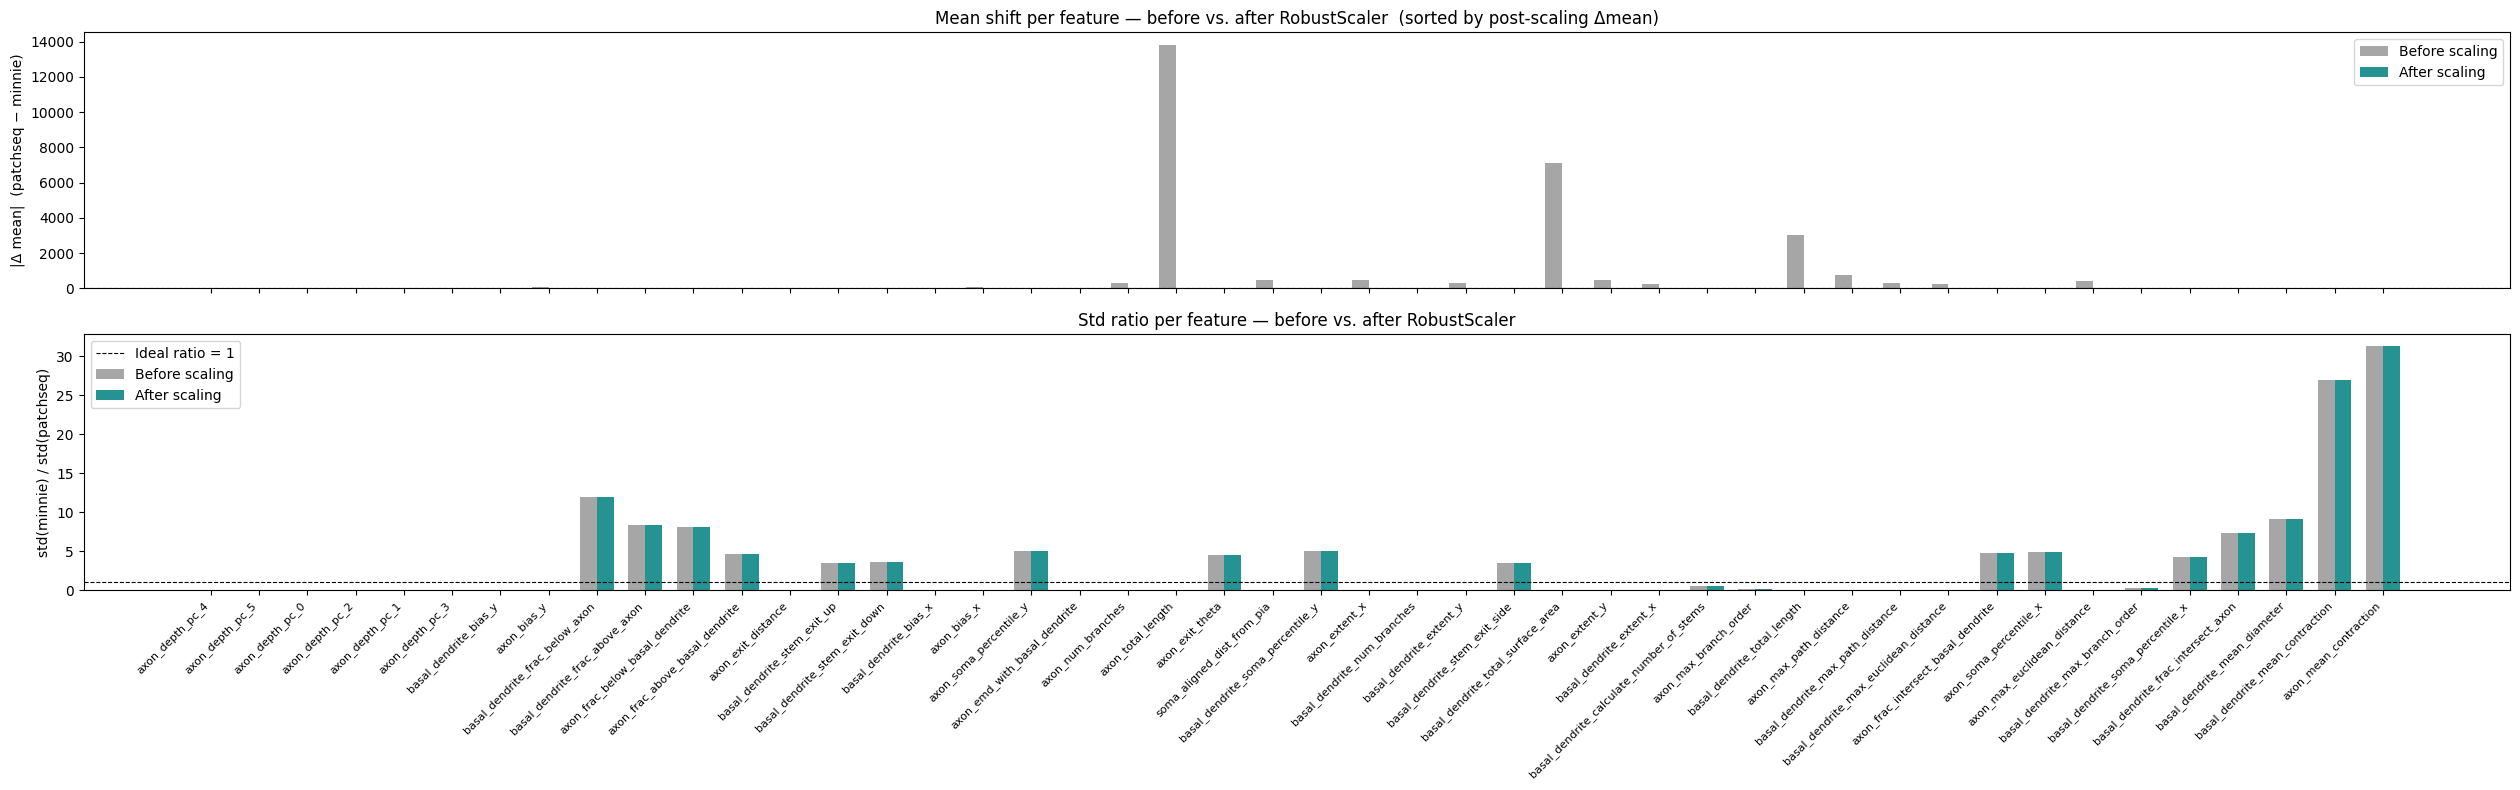

In [12]:
# ── Phase 3 Diagnostics: alignment summary bar chart (all features) ───────────
n_feats = len(alignment_df)
fig, axes = plt.subplots(2, 1, figsize=(max(12, n_feats * 0.55), 8), sharex=True)
x = np.arange(n_feats)
w = 0.35

# Top panel — |Δ mean| before vs. after
ax = axes[0]
ax.bar(x - w / 2, alignment_df["delta_mean_before"], width=w, color="grey",  alpha=0.7, label="Before scaling")
ax.bar(x + w / 2, alignment_df["delta_mean_after"],  width=w, color="teal",  alpha=0.85, label="After scaling")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("|Δ mean|  (patchseq − minnie)")
ax.set_title("Mean shift per feature — before vs. after RobustScaler  (sorted by post-scaling Δmean)")
ax.legend()

# Bottom panel — std ratio (minnie / patchseq)
ax = axes[1]
ax.bar(x - w / 2, alignment_df["std_ratio_before"], width=w, color="grey",  alpha=0.7, label="Before scaling")
ax.bar(x + w / 2, alignment_df["std_ratio_after"],  width=w, color="teal",  alpha=0.85, label="After scaling")
ax.axhline(1, color="black", linewidth=0.8, linestyle="--", label="Ideal ratio = 1")
ax.set_ylabel("std(minnie) / std(patchseq)")
ax.set_title("Std ratio per feature — before vs. after RobustScaler")
ax.set_xticks(x)
ax.set_xticklabels(alignment_df["feature"], rotation=45, ha="right", fontsize=8)
ax.legend()

fig.tight_layout()
plt.show()


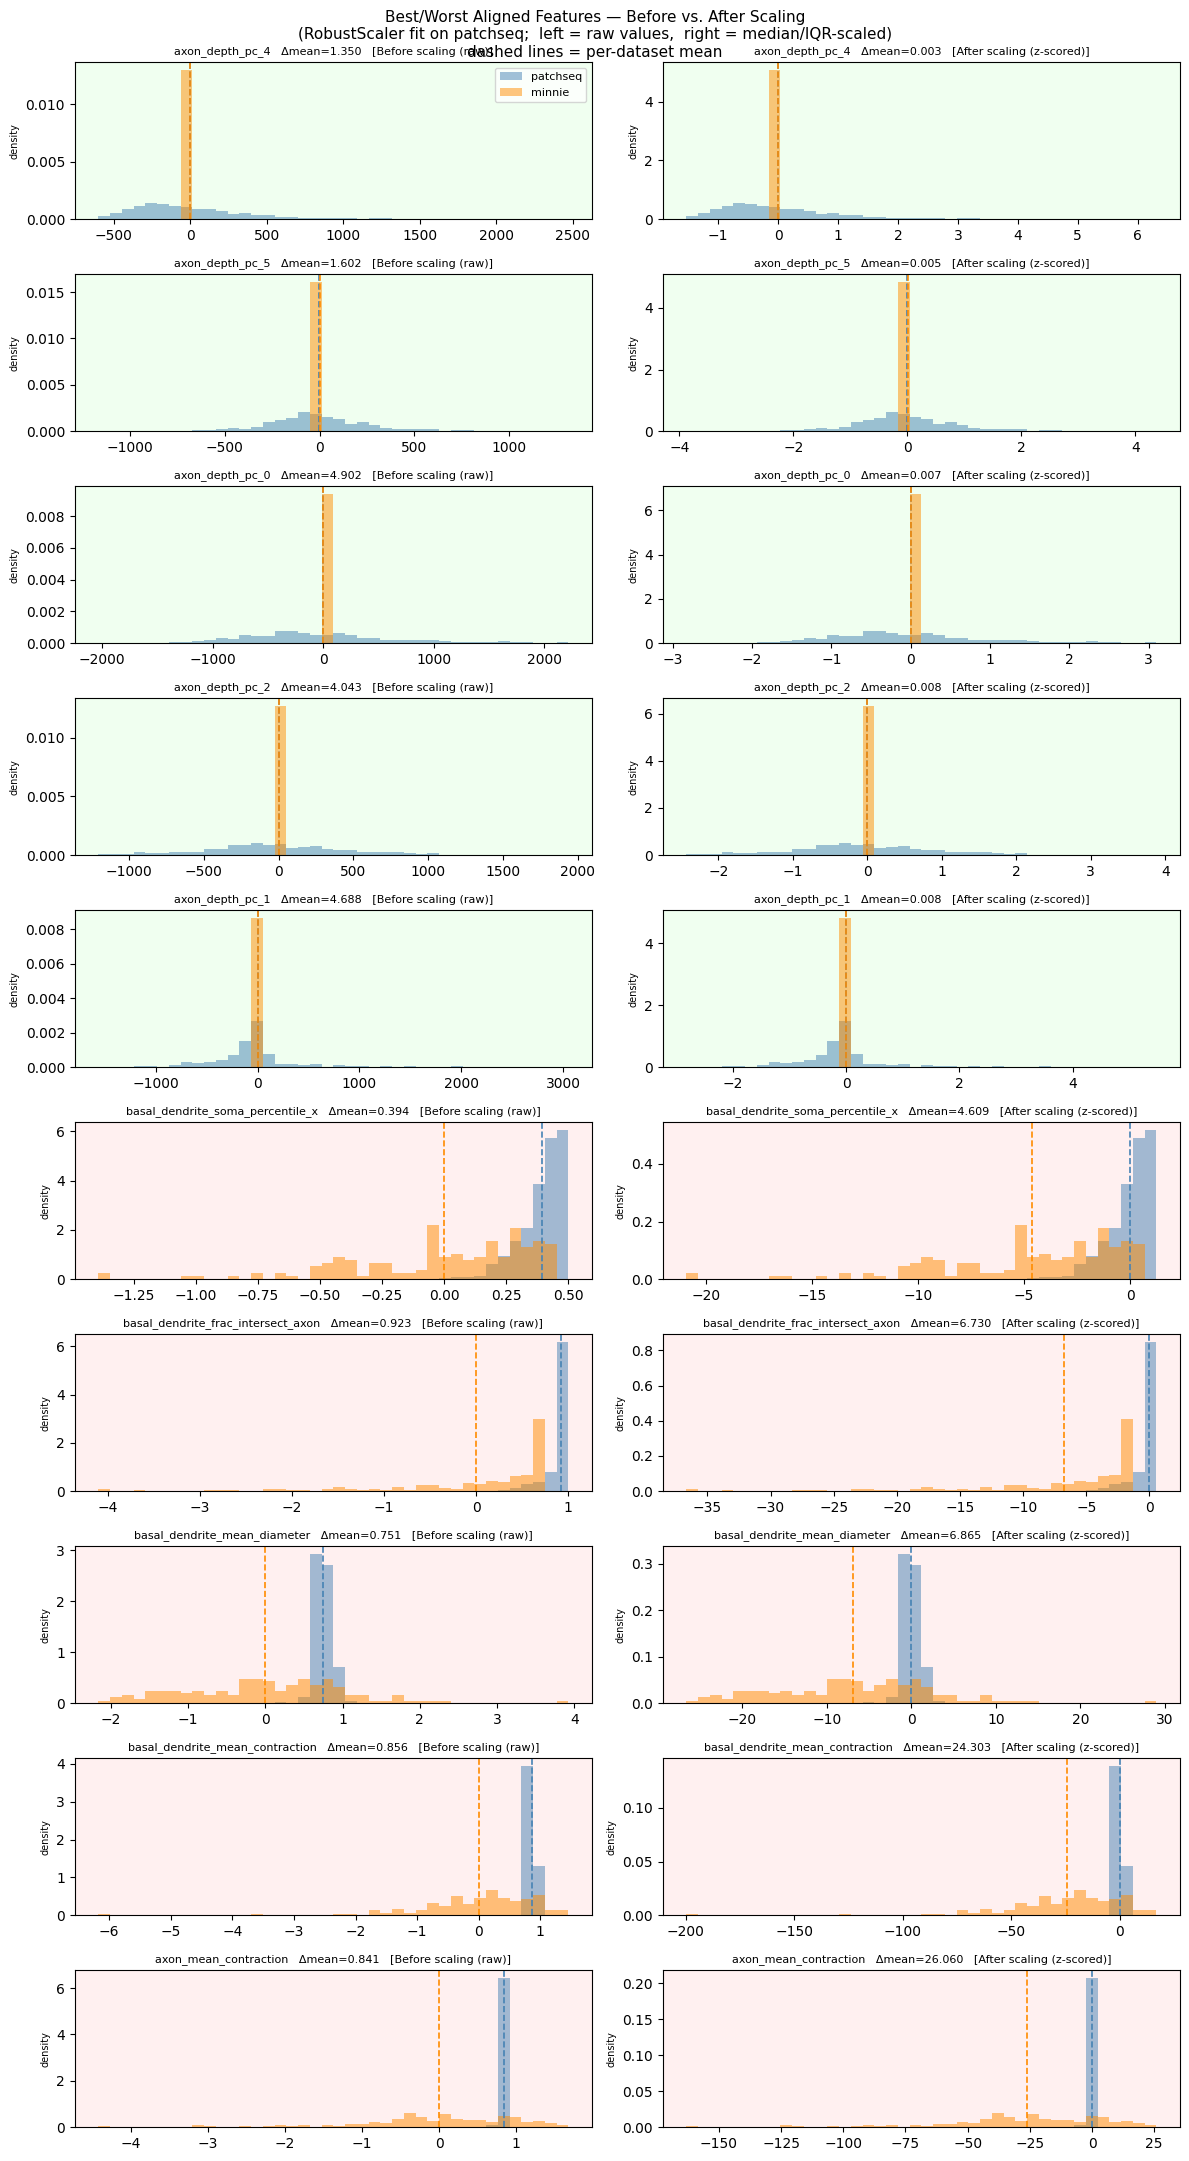

In [13]:
# ── Phase 3 Diagnostics: per-feature overlaid histograms (best & worst) ──────
TOP_N = 5  # number of best- and worst-aligned features to plot (adjust freely)
TOP_N = min(TOP_N, len(alignment_df) // 2)  # guard against too few features
N_BINS = 40

best_feats  = alignment_df.head(TOP_N)["feature"].tolist()
worst_feats = alignment_df.tail(TOP_N)["feature"].tolist()
plot_feats  = best_feats + worst_feats
sections    = ["best"] * TOP_N + ["worst"] * TOP_N

n_rows = len(plot_feats)
fig, axes = plt.subplots(n_rows, 2, figsize=(12, n_rows * 2.2), squeeze=False)
fig.suptitle(
    "Best/Worst Aligned Features — Before vs. After Scaling\n"
    "(RobustScaler fit on patchseq;  left = raw values,  right = median/IQR-scaled)\n"
    "dashed lines = per-dataset mean",
    fontsize=11,
)

BG_COLORS = {"best": "#f0fff0", "worst": "#fff0f0"}  # green tint = best, red tint = worst

for row_i, (feat, section) in enumerate(zip(plot_feats, sections)):
    feat_idx = shared_features.index(feat)
    row      = alignment_df.loc[alignment_df["feature"] == feat].iloc[0]
    deltas   = [row["delta_mean_before"], row["delta_mean_after"]]  # one per panel

    ps_raw, mn_raw = df_ps_pd[feat].values, df_mn_pd[feat].values
    ps_sc,  mn_sc  = X_ps[:, feat_idx],    X_mn[:, feat_idx]

    for col_i, (ps_vals, mn_vals, subtitle, delta) in enumerate([
        (ps_raw, mn_raw, "Before scaling (raw)",    deltas[0]),
        (ps_sc,  mn_sc,  "After scaling (z-scored)", deltas[1]),
    ]):
        combined_min = min(ps_vals.min(), mn_vals.min())
        combined_max = max(ps_vals.max(), mn_vals.max())
        bin_edges = np.linspace(combined_min, combined_max, N_BINS + 1)

        ax = axes[row_i, col_i]
        ax.set_facecolor(BG_COLORS[section])
        ax.hist(ps_vals, bins=bin_edges, density=True, alpha=0.5, color="steelblue",  label="patchseq")
        ax.hist(mn_vals, bins=bin_edges, density=True, alpha=0.5, color="darkorange", label="minnie")
        ax.axvline(ps_vals.mean(), color="steelblue",  linestyle="--", linewidth=1.2)
        ax.axvline(mn_vals.mean(), color="darkorange",  linestyle="--", linewidth=1.2)
        ax.set_title(f"{feat}   Δmean={delta:.3f}   [{subtitle}]", fontsize=8)
        ax.set_ylabel("density", fontsize=7)
        if row_i == 0 and col_i == 0:
            ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

### Phase 4 — UMAP Projection

In [14]:
# Fit UMAP on patchseq; project minnie into the same embedding space
reducer = umap.UMAP(n_components=2, random_state=42, init='random')
ps_emb = reducer.fit_transform(X_ps)
mn_emb = reducer.transform(X_mn)

print(f"Patchseq embedding: {ps_emb.shape}")
print(f"Minnie embedding:   {mn_emb.shape}")

/opt/conda/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Patchseq embedding: (495, 2)
Minnie embedding:   (163, 2)


### Phase 5 — KNN Label Transfer

In [15]:
# Fit KNN on patchseq embedding; query with minnie embedding
knn = NearestNeighbors(n_neighbors=3)
knn.fit(ps_emb)
_, indices = knn.kneighbors(mn_emb)

ps_labels = df_ps_pd['cluster'].values
neighbor_labels = ps_labels[indices]  # shape (n_minnie, 3)

# Majority vote per minnie cell
mn_predicted = np.array([
    Counter(row).most_common(1)[0][0] for row in neighbor_labels
])

print("Minnie predicted label counts:")
unique, counts = np.unique(mn_predicted, return_counts=True)
for lbl, cnt in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f"  {lbl:<45} {cnt}")

Minnie predicted label counts:
  Vip-MET-5                                     35
  Sncg-MET-1                                    28
  Vip-MET-1                                     28
  Lamp5-MET-1                                   11
  Pvalb-MET-4                                   10
  Sst-MET-9                                     9
  Vip-MET-4                                     8
  Sst-MET-7                                     6
  Sst-MET-12                                    5
  Pvalb-MET-1                                   4
  Sst-MET-10                                    4
  Sst-MET-3                                     4
  Sst-MET-6                                     3
  Vip-MET-2                                     2
  Pvalb-MET-5                                   1
  Sst-MET-1                                     1
  Sst-MET-13                                    1
  Sst-MET-2                                     1
  Sst-MET-4                                     1
  Vip-MET-3   

### Phase 6 — Visualisation

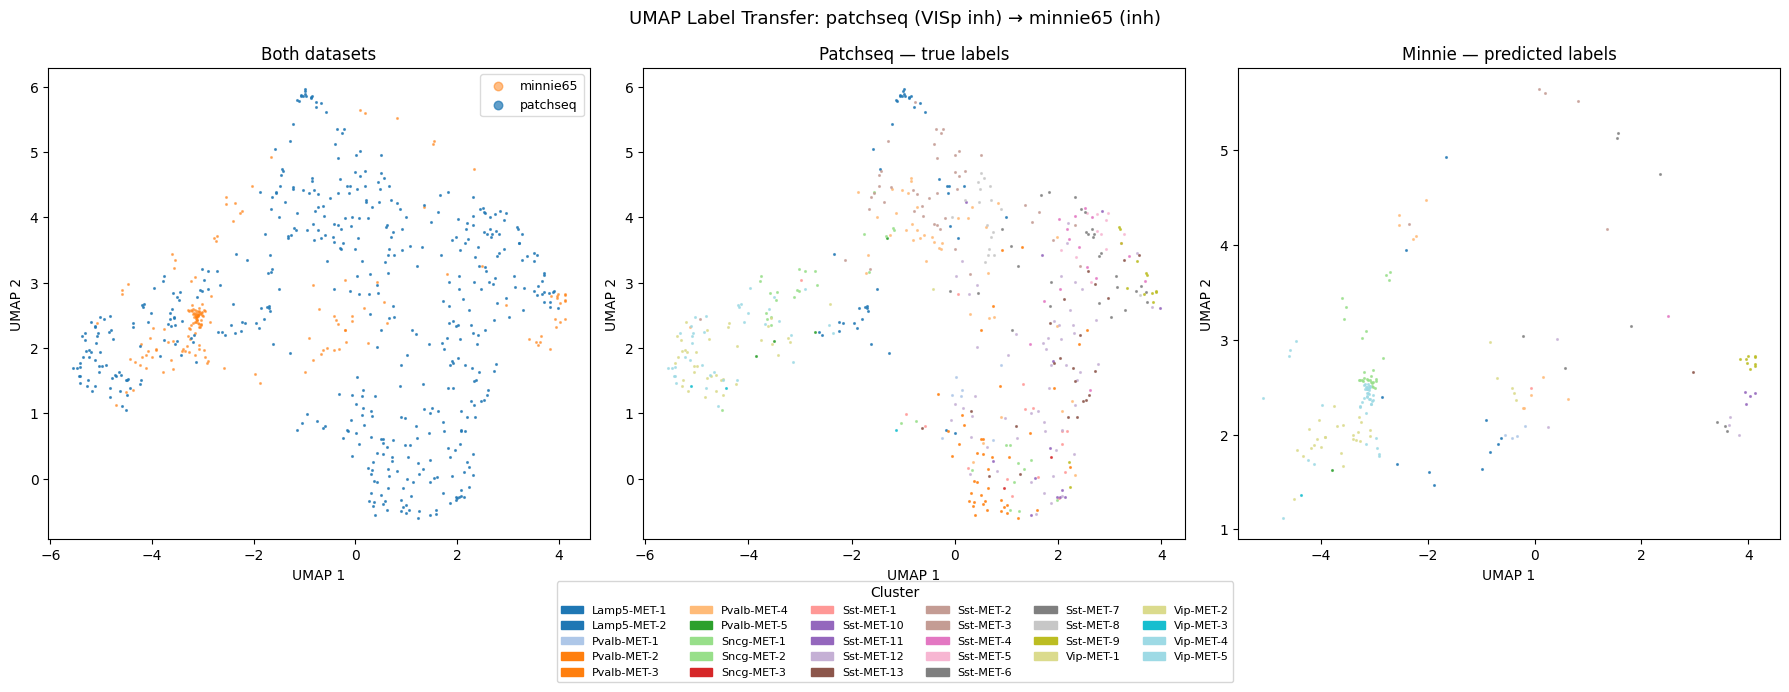

In [16]:
# ── Shared cluster colour map (tab20) ───────────────────────────────────────
all_cluster_labels = sorted(set(ps_labels) | set(mn_predicted))
cmap20 = plt.get_cmap('tab20')
cluster_colors = {
    lbl: cmap20(i / max(len(all_cluster_labels) - 1, 1))
    for i, lbl in enumerate(all_cluster_labels)
}

# Dataset-identity colours for the left panel
DS_COLORS = {'patchseq': '#1f77b4', 'minnie65': '#ff7f0e'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Left: both datasets, coloured by dataset identity ────────────────────────
ax = axes[0]
ax.scatter(mn_emb[:, 0], mn_emb[:, 1],
           c=DS_COLORS['minnie65'], s=1.5, alpha=0.5, rasterized=True, label='minnie65')
ax.scatter(ps_emb[:, 0], ps_emb[:, 1],
           c=DS_COLORS['patchseq'], s=1.5, alpha=0.7, rasterized=True, label='patchseq')
ax.set_title('Both datasets')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(markerscale=5, framealpha=0.7, fontsize=9)

# ── Middle: patchseq, coloured by true cluster label ─────────────────────────
ax = axes[1]
for lbl in all_cluster_labels:
    mask = ps_labels == lbl
    if mask.any():
        ax.scatter(ps_emb[mask, 0], ps_emb[mask, 1],
                   c=[cluster_colors[lbl]], s=1.5, alpha=0.7, rasterized=True)
ax.set_title('Patchseq — true labels')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# ── Right: minnie, coloured by predicted cluster label ───────────────────────
ax = axes[2]
for lbl in all_cluster_labels:
    mask = mn_predicted == lbl
    if mask.any():
        ax.scatter(mn_emb[mask, 0], mn_emb[mask, 1],
                   c=[cluster_colors[lbl]], s=1.5, alpha=0.7, rasterized=True)
ax.set_title('Minnie — predicted labels')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# ── Shared cluster legend (below middle + right panels) ──────────────────────
handles = [mpatches.Patch(color=cluster_colors[lbl], label=lbl) for lbl in all_cluster_labels]
fig.legend(
    handles=handles, title='Cluster',
    loc='lower center', ncol=min(len(all_cluster_labels), 6),
    bbox_to_anchor=(0.5, -0.15), framealpha=0.8, fontsize=8
)

plt.suptitle('UMAP Label Transfer: patchseq (VISp inh) → minnie65 (inh)', fontsize=13)
plt.tight_layout()
plt.show()